In [1]:
import os, signal, sys, time

sys.path.append(r'C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-')

from ai_economist import foundation

In [2]:
# Define a configuration (dictionary) for the "gather-trade-build" environment.

env_config_dict = {
    # ===== SCENARIO CLASS =====
    # Which Scenario class to use: the class's name in the Scenario Registry (foundation.scenarios).
    # The environment object will be an instance of the Scenario class.
    #'scenario_name': 'layout_from_file/simple_wood_and_stone',
    'scenario_name': 'custom/layout_with_starts',
        
        
    
    # ===== COMPONENTS =====
    # Which components to use (specified as list of ("component_name", {component_kwargs}) tuples).
    #   "component_name" refers to the Component class's name in the Component Registry (foundation.components)
    #   {component_kwargs} is a dictionary of kwargs passed to the Component class
    # The order in which components reset, step, and generate obs follows their listed order below.
    'components': [
        # (1) Building houses
        ('Build', {
            'skill_dist':                   'pareto', 
            'payment_max_skill_multiplier': 3,
            'build_labor':                  10,
            'payment':                      10
        }),
        # (2) Trading collectible resources
        ('ContinuousDoubleAuction', {
            'max_bid_ask':    10,
            'order_labor':    0.25,
            'max_num_orders': 5,
            'order_duration': 50
        }),
        # (3) Movement and resource collection
        ('Gather', {
            'move_labor':    1, #prev 1
            'collect_labor': 1,
            'skill_dist':    'pareto'
        }),
        # (4) Planner
        ('PeriodicBracketTax', {
            'period':          100,
            'bracket_spacing': 'us-federal',
            'usd_scaling':     1000,
            'disable_taxes':   False
        })
    ],
    
    # ===== SCENARIO CLASS ARGUMENTS =====
    # (optional) kwargs that are added by the Scenario class (i.e. not defined in BaseEnvironment)
    'env_layout_file': 'map_100x50_water_gaps_3percent_resources.txt',
    'starting_agent_coin': 10,
    'fixed_four_skill_and_loc': False, #should be true
    
    # ===== STANDARD ARGUMENTS ======
    # kwargs that are used by every Scenario class (i.e. defined in BaseEnvironment)
    'n_agents': 4,          # Number of non-planner agents (must be > 1)
    #'world_size': [25, 25], # [Height, Width] of the env world
    'world_size': [100, 50],
    'episode_length': 1000, # Number of timesteps per episode
    
    # In multi-action-mode, the policy selects an action for each action subspace (defined in component code).
    # Otherwise, the policy selects only 1 action.
    'multi_action_mode_agents': True,
    'multi_action_mode_planner': True,
    
    # When flattening observations, concatenate scalar & vector observations before output.
    # Otherwise, return observations with minimal processing.
    'flatten_observations': True,
    # When Flattening masks, concatenate each action subspace mask into a single array.
    # Note: flatten_masks = True is required for masking action logits in the code below.
    'flatten_masks': True,
    
    # How often to save the dense logs
    'dense_log_frequency': 1
}

In [3]:
from rllib.env_wrapper import RLlibEnvWrapper
env_obj = RLlibEnvWrapper({"env_config_dict": env_config_dict}, verbose=True)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
c:\Users\adria\anaconda3\envs\ai-economist\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\Users\adria\anaconda3\envs\ai-economist\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in

[EnvWrapper] Spaces
[EnvWrapper] Obs (a)   
action_mask    : (55,)
flat           : (136,)
time           : (1,)
world-idx_map  : (2, 11, 11)
world-map      : (7, 11, 11)


[EnvWrapper] Obs (p)
  [p]
action_mask    : (154,)
flat           : (86,)
p0             : (8,)
p1             : (8,)
p2             : (8,)
p3             : (8,)
time           : (1,)
world-idx_map  : (2, 100, 50)
world-map      : (6, 100, 50)


[EnvWrapper] Action (a) MultiDiscrete([ 2 12 12 12 12  5])
[EnvWrapper] Action (p) {'p': MultiDiscrete([22 22 22 22 22 22 22])}


In [4]:
import ray
from ray.rllib.agents.ppo import PPOTrainer

In [5]:
policies = {
    "a": (
        None,  # uses default policy
        env_obj.observation_space,
        env_obj.action_space,
        {}  # define a custom agent policy configuration.
    ),
    "p": (
        None,  # uses default policy
        env_obj.observation_space_pl,
        env_obj.action_space_pl,
        {}  # define a custom planner policy configuration.
    )
}

# In foundation, all the agents have integer ids and the social planner has an id of "p"
policy_mapping_fun = lambda i: "a" if str(i).isdigit() else "p"

policies_to_train = ["a", "p"]

In [6]:
trainer_config = {
    "multiagent": {
        "policies": policies,
        "policies_to_train": policies_to_train,
        "policy_mapping_fn": policy_mapping_fun,
    }
}

trainer_config.update(
    {
        "num_workers": 0,
        "num_envs_per_worker": 2,
        # Other training parameters
        "train_batch_size":  4000,
        "sgd_minibatch_size": 4000,
        "num_sgd_iter": 1
    }
)

In [ ]:
# We also add the "num_envs_per_worker" parameter for the env. wrapper to index the environments.
env_config = {
    "env_config_dict": env_config_dict,
    "num_envs_per_worker": trainer_config.get('num_envs_per_worker'),   
}

trainer_config.update(
    {
        "env_config": env_config        
    }
)

: 

In [ ]:
ray.init(webui_host="127.0.0.1")

2026-03-16 17:15:35,929	INFO resource_spec.py:212 -- Starting Ray with 2.73 GiB memory available for workers and up to 1.39 GiB for objects. You can adjust these settings with ray.init(memory=<bytes>, object_store_memory=<bytes>).
2026-03-16 17:15:36,298	INFO services.py:1165 -- View the Ray dashboard at 127.0.0.1:8265


In [ ]:
# Create the PPO trainer.
trainer = PPOTrainer(
    env=RLlibEnvWrapper,
    config=trainer_config,
    )

2026-03-12 14:59:05,826	ERROR syncer.py:46 -- Log sync requires rsync to be installed.
2026-03-12 14:59:05,829	INFO trainer.py:585 -- Tip: set framework=tfe or the --eager flag to enable TensorFlow eager execution
2026-03-12 14:59:05,829	INFO trainer.py:612 -- Current log_level is WARN. For more information, set 'log_level': 'INFO' / 'DEBUG' or use the -v and -vv flags.


ValueError: policy tuple value 1 (observation_space) must be a gym.Space, got <class 'dict'>

(pid=None) F0312 15:11:59.184588 19772  7828 redis_client.cc:69]  Check failed: num_attempts < RayConfig::instance().redis_db_connect_retries() Expected 1 Redis shard addresses, found 2
(pid=None) *** Check failure stack trace: ***
(pid=None)     @   00007FF65C57608C  public: __cdecl google::LogMessage::~LogMessage(void) __ptr64
(pid=None)     @   00007FF65C28CFB4  public: virtual __cdecl google::NullStreamFatal::~NullStreamFatal(void) __ptr64
(pid=None)     @   00007FF65C4E5F8B  public: void __cdecl google::NullStreamFatal::`vbase destructor'(void) __ptr64
(pid=None)     @   00007FF65C4E524B  public: void __cdecl google::NullStreamFatal::`vbase destructor'(void) __ptr64
(pid=None)     @   00007FF65C26E419  public: class google::NullStream & __ptr64 __cdecl google::NullStream::stream(void) __ptr64
(pid=None)     @   00007FF65C26463B  public: class google::NullStream & __ptr64 __cdecl google::NullStream::stream(void) __ptr64
(pid=None)     @   00007FF65C223787  Ordinal0
(pid=None)     @

2026-03-13 14:24:37,565	ERROR worker.py:1049 -- listen_error_messages_raylet: Connection closed by server.
2026-03-13 14:24:37,568	ERROR import_thread.py:93 -- ImportThread: Connection closed by server.
2026-03-13 14:24:37,569	ERROR worker.py:949 -- print_logs: Connection closed by server.


In [ ]:
# import ray
# ray.shutdown()
# ray.init(ignore_reinit_error=True)

2026-03-10 17:14:09,362	INFO resource_spec.py:212 -- Starting Ray with 1.03 GiB memory available for workers and up to 0.52 GiB for objects. You can adjust these settings with ray.init(memory=<bytes>, object_store_memory=<bytes>).
2026-03-10 17:14:09,614	INFO services.py:1165 -- View the Ray dashboard at localhost:8265


{'node_ip_address': '192.168.1.108',
 'raylet_ip_address': '192.168.1.108',
 'redis_address': '192.168.1.108:6379',
 'object_store_address': 'tcp://127.0.0.1:65079',
 'raylet_socket_name': 'tcp://127.0.0.1:65520',
 'webui_url': 'localhost:8265',
 'session_dir': 'C:\\Users\\adria\\AppData\\Local\\Temp\\ray\\session_2026-03-10_17-14-09_355968_18960'}

In [ ]:
NUM_ITERS = 10
for iteration in range(NUM_ITERS):
    print(f'********** Iter : {iteration} **********')
    result = trainer.train()
    print(f'''episode_reward_mean: {result.get('episode_reward_mean')}''')

********** Iter : 0 **********


2026-03-10 17:14:13,483	WARNING worker.py:1047 -- The dashboard on node adbo-desktop failed with the following error:
Traceback (most recent call last):
  File "c:\Users\adria\anaconda3\envs\ai-economist\lib\site-packages\ray\dashboard/dashboard.py", line 960, in <module>
    metrics_export_address=metrics_export_address)
  File "c:\Users\adria\anaconda3\envs\ai-economist\lib\site-packages\ray\dashboard/dashboard.py", line 513, in __init__
    build_dir = setup_static_dir(self.app)
  File "c:\Users\adria\anaconda3\envs\ai-economist\lib\site-packages\ray\dashboard/dashboard.py", line 414, in setup_static_dir
    "&& npm run build)", build_dir)
FileNotFoundError: [Errno 2] Dashboard build directory not found. If installing from source, please follow the additional steps required to build the dashboard(cd python/ray/dashboard/client && npm ci && npm run build): 'c:\\Users\\adria\\anaconda3\\envs\\ai-economist\\lib\\site-packages\\ray\\dashboard\\client/build'



episode_reward_mean: -35.21756177463283
********** Iter : 1 **********
episode_reward_mean: -26.946329229757627
********** Iter : 2 **********
episode_reward_mean: -30.56901961815302
********** Iter : 3 **********
episode_reward_mean: -29.271128209990092
********** Iter : 4 **********
episode_reward_mean: -29.491431974310366
********** Iter : 5 **********
episode_reward_mean: -31.17695607069523
********** Iter : 6 **********
episode_reward_mean: -31.11705672101063
********** Iter : 7 **********
episode_reward_mean: -29.920195710841778
********** Iter : 8 **********
episode_reward_mean: -30.40927813088255
********** Iter : 9 **********
episode_reward_mean: -29.8424328163557


# creating the logs

In [ ]:
def generate_rollout_from_current_trainer_policy(
    trainer, 
    env_obj,
    num_dense_logs=1
):
    dense_logs = {}
    for idx in range(num_dense_logs):
        # Set initial states
        agent_states = {}
        for agent_idx in range(env_obj.env.n_agents):
            agent_states[str(agent_idx)] = trainer.get_policy("a").get_initial_state()
        planner_states = trainer.get_policy("p").get_initial_state()   

        # Play out the episode
        steps = 0
        obs = env_obj.reset(force_dense_logging=True)
        for t in range(env_obj.env.episode_length):
            actions = {}
            for agent_idx in range(env_obj.env.n_agents):
                # Use the trainer object directly to sample actions for each agent
                actions[str(agent_idx)] = trainer.compute_action(
                    obs[str(agent_idx)], 
                    agent_states[str(agent_idx)], 
                    policy_id="a",
                    full_fetch=False
                )
            
            # Action sampling for the planner
            actions["p"] = trainer.compute_action(
                obs['p'], 
                planner_states, 
                policy_id='p',
                full_fetch=False
            )
            steps += 1
            obs, rew, done, info = env_obj.step(actions)        
            if done['__all__']:
                break

        #print("Episode length:", steps)
        import copy
        dense_logs[idx] = copy.deepcopy(env_obj.env.dense_log) #new

        




    return dense_logs

In [ ]:
import numpy as np

def generate_rollout_from_current_trainer_policy_with_tax(
    trainer, 
    env_obj,
    num_dense_logs=1
):
    dense_logs = {}
    for idx in range(num_dense_logs):
        # Set initial states
        agent_states = {}
        for agent_idx in range(env_obj.env.n_agents):
            agent_states[str(agent_idx)] = trainer.get_policy("a").get_initial_state()
        planner_states = trainer.get_policy("p").get_initial_state()   

        # Container for tax logs at 1, 101, 201, 301, ...
        tax_rates_every_100 = {}

        # Play out the episode
        obs = env_obj.reset(force_dense_logging=True)
        for t in range(env_obj.env.episode_length):
            actions = {}
            for agent_idx in range(env_obj.env.n_agents):
                actions[str(agent_idx)] = trainer.compute_action(
                    obs[str(agent_idx)], 
                    agent_states[str(agent_idx)], 
                    policy_id="a",
                    full_fetch=False
                )

            # Planner action
            actions["p"] = trainer.compute_action(
                obs['p'], 
                planner_states, 
                policy_id='p',
                full_fetch=False
            )

            # ---- Log tax rates at timesteps 1, 101, 201, ... (1-based) ----
            if (t + 1) % 100 == 1:
                tax = env_obj.env.get_component("PeriodicBracketTax")
                rates = tax.curr_marginal_rates() if callable(tax.curr_marginal_rates) else tax.curr_marginal_rates
                tax_rates_every_100[t + 1] = np.array(rates, copy=True)

            # Step environment
            obs, rew, done, info = env_obj.step(actions)        
            if done['__all__']:
                break

        dense_logs[idx] = env_obj.env.dense_log
        dense_logs[idx]["tax_rates_every_100"] = tax_rates_every_100

    return dense_logs

In [ ]:
dense_logs = generate_rollout_from_current_trainer_policy(
    trainer, 
    env_obj,
    num_dense_logs=10
)

In [ ]:
tax = env_obj.env.get_component("PeriodicBracketTax")
print("Taxes disabled:", tax.disable_taxes)
print("Tax period:", tax.period)

Taxes disabled: False
Tax period: 100


In [ ]:
episode = list(dense_logs.keys())[0]
for k in dense_logs[episode].keys():
    print(k)

world
states
actions
rewards
Build
Trade
Gather
PeriodicTax


# Debug

In [ ]:
import numpy as np
from scipy.stats import entropy

entropies = []

for ep in dense_logs:
    if "p" not in dense_logs[ep]["actions"]:
        continue

    actions = np.asarray(dense_logs[ep]["actions"]["p"]).flatten()
    if len(actions) == 0:
        continue

    probs = np.bincount(actions) / len(actions)
    entropies.append(entropy(probs))

print("Planner action entropy:", np.mean(entropies))

Planner action entropy: nan


c:\Users\adria\anaconda3\envs\ai-economist\lib\site-packages\numpy\core\fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
c:\Users\adria\anaconda3\envs\ai-economist\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(type(dense_logs))
print(dense_logs.keys())
print(len(dense_logs))

print(dense_logs[0].keys())

print(len(env_obj.env.dense_log))
print(env_obj.env.dense_log.keys())

<class 'dict'>
dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
10
dict_keys(['world', 'states', 'actions', 'rewards', 'Build', 'Trade', 'Gather', 'PeriodicTax'])
8
dict_keys(['world', 'states', 'actions', 'rewards', 'Build', 'Trade', 'Gather', 'PeriodicTax'])


In [ ]:
obs = env_obj.reset()

planner_action = trainer.compute_action(
    obs["p"],
    policy_id="p",
    explore=False
)

print("Planner action:", planner_action)

Planner action: [12  7  6  0  4  9 11]


In [ ]:
for c in env_obj.env.components:
    print(type(c).__name__)

Build
ContinuousDoubleAuction
Gather
PeriodicBracketTax


In [ ]:
for ep in dense_logs:
    print("Episode", ep)
    print("Keys:", dense_logs[ep].keys())
    break

Episode 0
Keys: dict_keys(['world', 'states', 'actions', 'rewards', 'Build', 'Trade', 'Gather', 'PeriodicTax'])


- dense_logs[0] and dense_logs[1] are two different episodes (rollouts) generated back‑to‑back with the same trainer/policies. 
- Plotting index 0 visualizes the first episode collected; plotting index 1 visualizes the second. 
- Any differences you see come from the environment/policy stochasticity and reset conditions between episodes.
- We should have num_workers x num_envs_per_worker number of dense logs.

In [ ]:
actions = []

for ep in dense_logs:
    log = dense_logs[ep]
    if "planner_actions" in log:
        actions.append(log["planner_actions"])

print("Episodes analyzed:", len(actions))

Episodes analyzed: 0


In [ ]:
print(trainer.get_policy("p").model)

In [ ]:
# import numpy as np

# rate_levels = np.linspace(0,1,21)

# planner_actions = dense_logs[0]["planner_actions"]

# tax_rates = rate_levels[planner_actions]

In [ ]:
# import matplotlib.pyplot as plt

# final_tax = tax_rates[-1]

# plt.figure(figsize=(8,4))
# plt.plot(final_tax, marker="o")
# plt.xlabel("Tax bracket")
# plt.ylabel("Marginal tax rate")
# plt.title("Final learned tax system")
# plt.ylim(0,1)
# plt.grid()
# plt.show()

In [ ]:
# np.std(planner_actions, axis=0)

# mean_tax = tax_rates.mean(axis=1)

# plt.figure(figsize=(8,4))
# plt.plot(mean_tax)
# plt.xlabel("Timestep")
# plt.ylabel("Average marginal tax")
# plt.title("Planner tax decisions over time")
# plt.grid()
# plt.show()

In [ ]:
# print("Final tax rates:", final_tax)

# END DEBUG

_______________:_ Agent  0 _____|_ Agent  1 _____|_ Agent  2 _____|_ Agent  3 ____
Cost (Wood)    :   6.00 (n=  5) |   7.25 (n=  4) |   7.75 (n=  4) |    ~~~~~~~~   
Cost (Stone)   :   3.65 (n= 17) |   2.73 (n= 15) |   3.90 (n= 21) |   3.62 (n=  8)

Income (Wood)  :   9.25 (n=  4) |   7.00 (n=  3) |   5.33 (n=  6) |    ~~~~~~~~   
Income (Stone) :   4.00 (n= 16) |   3.62 (n= 13) |   3.32 (n= 25) |   2.86 (n=  7)
Income (Build) :  11.33 (n=  1) |  13.27 (n=  1) |    ~~~~~~~~    |    ~~~~~~~~   


((<Figure size 1152x216 with 5 Axes>,
  <Figure size 1152x288 with 4 Axes>,
  <Figure size 1152x576 with 8 Axes>),
 {'Sell Stone': [64, 47, 83, 20],
  'Buy Stone': [-62, -41, -82, -29],
  'Sell Wood': [37, 21, 32, 0],
  'Buy Wood': [-30, -29, -31, 0],
  'Build': [11.331640623590097, 13.267112338979295, 0, 0],
  'Total': array([20.33164062, 11.26711234,  2.        , -9.        ])},
 [29, 19, 12, 2],
 {'Stone': [{'t': 162,
    't_ask': 162,
    't_bid': 124,
    'commodity': 'Stone',
    'buyer': 2,
    'bid': 3,
    'bid_lifetime': 38,
    'seller': 0,
    'ask': 0,
    'ask_lifetime': 0,
    'price': 3,
    'cost': 3,
    'income': 3},
   {'t': 166,
    't_ask': 166,
    't_bid': 121,
    'commodity': 'Stone',
    'buyer': 3,
    'bid': 2,
    'bid_lifetime': 45,
    'seller': 2,
    'ask': 0,
    'ask_lifetime': 0,
    'price': 2,
    'cost': 2,
    'income': 2},
   {'t': 170,
    't_ask': 170,
    't_bid': 167,
    'commodity': 'Stone',
    'buyer': 0,
    'bid': 4,
    'bid_lifetime

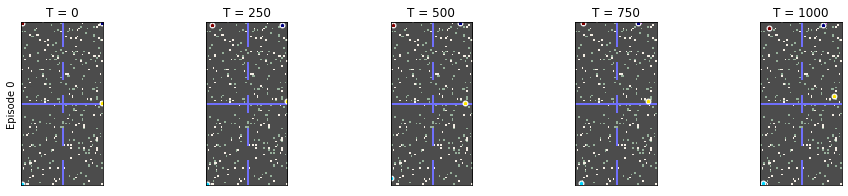

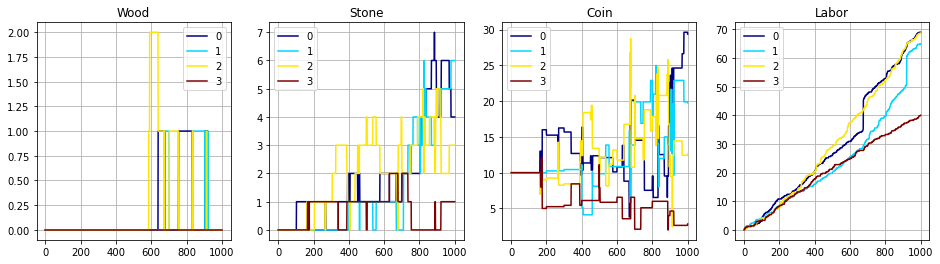

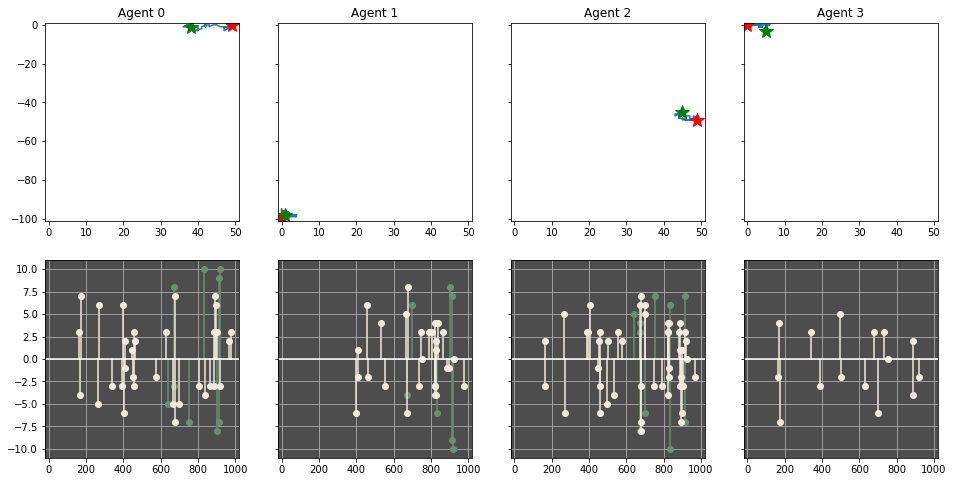

In [ ]:
from utils import plotting  # plotting utilities for visualizing env. state

plotting.breakdown(dense_logs[0])


# brorman den sætter kun hver 100 

In [ ]:
tax_comp = env_obj.env.get_component("PeriodicBracketTax")

print("Current marginal tax rates:")
print(tax_comp.curr_marginal_rates)

Current marginal tax rates:
[0. 0. 0. 0. 0. 0. 0.]


In [ ]:
from ai_economist import foundation
import numpy as np

env = foundation.make_env_instance(**env_config_dict)
obs = env.reset()

planner = env.world.planner
tax = env.get_component("PeriodicBracketTax")

print("\n=== START OF TRACE ===")
print("Planner idx:", planner.idx)
print("Planner action_dim:", planner.action_dim)
print("n_disc_rates:", tax.n_disc_rates)
print("tax_cycle_pos:", tax.tax_cycle_pos)
print()

# ==== 1. Your sampler's output (we fake it here) ====
sampled = [5, 7, 10, 12, 14, 15, 20]   # random legal non-zero actions
print("1) Sampler output:", sampled)

# ==== 2. Let RLlibEnvWrapper process the actions ====
try:
    # build minimal action dict like RLlib would
    wrapper_actions = {planner.idx: np.array(sampled)}

    # RLlib wrapper applies action processing in step()
    # so we need to simulate one step call
    # we do a trick: call env.step and intercept what goes into Foundation
    # But Foundation env is env_obj.env inside wrapper, so we skip wrapper

    print("2) Giving to env.step() raw:", wrapper_actions)

    # ==== 3. Call step and capture what FOUNDATION receives ====
    # Workers no-op
    for ag in env.world.agents:
        wrapper_actions[str(ag.idx)] = 0

    obs2, rew, done, info = env.step(wrapper_actions)

    print("3) After env.step(), tax.curr_rate_indices:", tax.curr_rate_indices)
    print("   tax.curr_marginal_rates:", tax.curr_marginal_rates)

except Exception as e:
    print("ERROR:", e)

print("\n=== TRACE END ===\n")


=== START OF TRACE ===
Planner idx: p
Planner action_dim: {'PeriodicBracketTax.TaxIndexBracket_000': 22, 'PeriodicBracketTax.TaxIndexBracket_009': 22, 'PeriodicBracketTax.TaxIndexBracket_039': 22, 'PeriodicBracketTax.TaxIndexBracket_084': 22, 'PeriodicBracketTax.TaxIndexBracket_160': 22, 'PeriodicBracketTax.TaxIndexBracket_204': 22, 'PeriodicBracketTax.TaxIndexBracket_510': 22}
n_disc_rates: 21
tax_cycle_pos: 1

1) Sampler output: [5, 7, 10, 12, 14, 15, 20]
2) Giving to env.step() raw: {'p': array([ 5,  7, 10, 12, 14, 15, 20])}
3) After env.step(), tax.curr_rate_indices: [4, 6, 9, 11, 13, 14, 19]
   tax.curr_marginal_rates: [0.2  0.3  0.45 0.55 0.65 0.7  0.95]

=== TRACE END ===



In [ ]:
def generate_rollout_with_planner_actions(
    trainer,
    env_obj,
    num_dense_logs=10
):
    dense_logs = {}

    for idx in range(num_dense_logs):
        # Reset RNN states
        agent_states = {
            str(agent_idx): trainer.get_policy("a").get_initial_state()
            for agent_idx in range(env_obj.env.n_agents)
        }
        planner_states = trainer.get_policy("p").get_initial_state()

        obs = env_obj.reset(force_dense_logging=True)

        planner_actions_log = []

        for t in range(env_obj.env.episode_length):

            # Collect agent actions
            actions = {}
            for agent_idx in range(env_obj.env.n_agents):
                act = trainer.compute_action(
                    obs[str(agent_idx)],
                    agent_states[str(agent_idx)],
                    policy_id="a",
                    full_fetch=False
                )
                actions[str(agent_idx)] = act

            # Collect the planner action
            p_act = trainer.compute_action(
                obs["p"],
                planner_states,
                policy_id="p",
                full_fetch=False
            )
            actions["p"] = p_act

            planner_actions_log.append(p_act)

            obs, rew, done, info = env_obj.step(actions)
            if done["__all__"]:
                break

        # Copy Foundation's dense log and extend with planner actions
        dense_logs[idx] = dict(env_obj.env.dense_log)
        dense_logs[idx]["planner_actions"] = np.array(planner_actions_log)

    return dense_logs

In [ ]:
dense_logs = generate_rollout_with_planner_actions(
    trainer,
    env_obj,
    num_dense_logs=10
)

_______________:_ Agent  0 _____|_ Agent  1 _____|_ Agent  2 _____|_ Agent  3 ____
Cost (Wood)    :   4.40 (n=  5) |   4.75 (n=  4) |   4.57 (n=  7) |   6.25 (n=  4)
Cost (Stone)   :   3.09 (n= 11) |   4.31 (n= 13) |   4.12 (n= 16) |   4.00 (n=  6)

Income (Wood)  :   4.50 (n=  4) |   5.50 (n=  4) |   5.00 (n=  9) |   4.33 (n=  3)
Income (Stone) :   3.70 (n= 10) |   4.13 (n= 15) |   3.50 (n= 16) |   5.00 (n=  5)
Income (Build) :    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~   


array([[10,  3,  9, ..., 18,  3, 18],
       [ 4,  6,  7, ..., 13,  4,  0],
       [12, 18, 19, ..., 10,  3,  7],
       ...,
       [16, 19,  1, ..., 21, 13, 20],
       [ 5, 18,  3, ..., 18, 11, 18],
       [12, 19,  8, ...,  2,  3,  5]], dtype=int64)

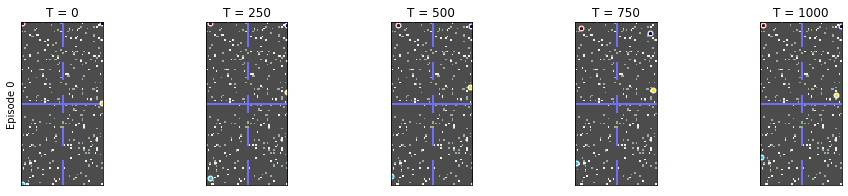

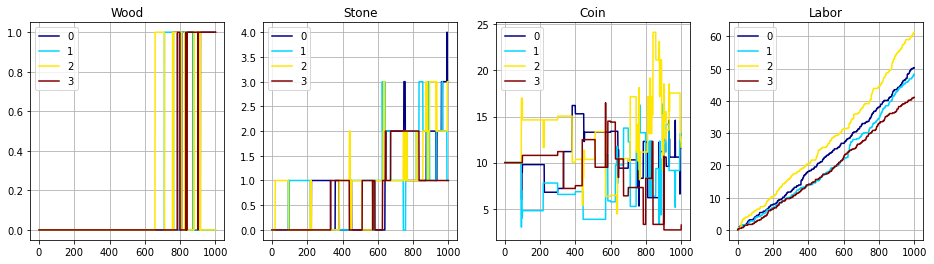

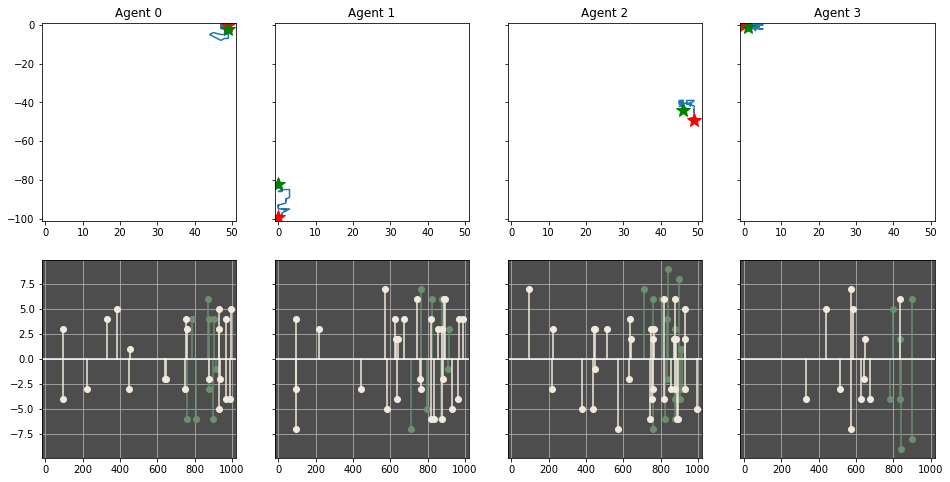

In [ ]:
plotting.breakdown(dense_logs[0])   # agent actions (unchanged)
dense_logs[0]["planner_actions"]    # <-- your new planner actions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_final_tax_schedule(dense_logs):

    planner_actions = dense_logs[0]["planner_actions"]
    final_actions = planner_actions[-1]

    rate_levels = np.linspace(0, 0.8, 21)
    marginal_rates = rate_levels[final_actions-1]

    usd_scaling = 1000

    brackets = np.array([
        0,
        9700,
        39475,
        84200,
        160725,
        204100,
        510300
    ]) / usd_scaling

    n = min(len(brackets), len(marginal_rates)) #can be left out

    plt.step(brackets[:n], marginal_rates[:n], where="post") #can be left out

    plt.figure(figsize=(8,5))

    plt.step(brackets[:len(marginal_rates)], marginal_rates, where="post")
    plt.fill_between(brackets[:len(marginal_rates)], marginal_rates, step="post", alpha=0.3)

    plt.xlabel("Income (Coin)")
    plt.ylabel("Marginal Tax Rate")
    plt.title("Final Planner Tax Schedule")

    plt.ylim(0,1)
    plt.grid(True)

    plt.show()

In [ ]:
print(dense_logs.keys())

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


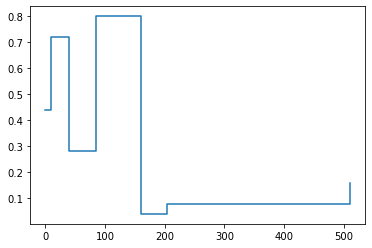

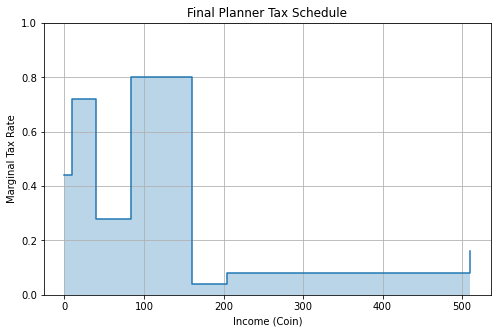

In [ ]:
plot_final_tax_schedule(dense_logs)

In [ ]:
import numpy as np

episodes = sorted(dense_logs.keys())

actions = []
for ep in episodes:
    log = dense_logs[ep]
    if "planner_actions" in log:
        actions.append(np.asarray(log["planner_actions"]))

if len(actions) == 0:
    print("No planner_actions found.")
else:
    # average action index per episode
    episode_means = [a.mean() for a in actions]

    print("First episodes:", episode_means[:5])
    print("Last episodes :", episode_means[-5:])

First episodes: [10.515857142857143, 10.472, 10.423285714285715, 10.527714285714286, 10.457285714285714]
Last episodes : [10.470142857142857, 10.571714285714286, 10.47942857142857, 10.46642857142857, 10.401285714285715]


In [ ]:
from scipy.stats import entropy
import numpy as np

entropies = []

for ep in sorted(dense_logs.keys()):
    log = dense_logs[ep]
    if "planner_actions" not in log:
        continue
        
    a = np.asarray(log["planner_actions"]).flatten()
    counts = np.bincount(a)
    probs = counts / counts.sum()
    entropies.append(entropy(probs))

print("Early entropy:", np.mean(entropies[:5]))
print("Late entropy :", np.mean(entropies[-5:]))

Early entropy: 3.0895182069158147
Late entropy : 3.0895975203157473


In [ ]:
for ep in dense_logs:
    a = np.asarray(dense_logs[ep]["planner_actions"])
    print(ep, "mean:", a.mean(), "std:", a.std())

0 mean: 10.515857142857143 std: 6.330157297268629
1 mean: 10.472 std: 6.3810714729469336
2 mean: 10.423285714285715 std: 6.3623985192981545
3 mean: 10.527714285714286 std: 6.326820725277106
4 mean: 10.457285714285714 std: 6.368350632268155
5 mean: 10.470142857142857 std: 6.382920959842119
6 mean: 10.571714285714286 std: 6.259940659560959
7 mean: 10.47942857142857 std: 6.354605053640636
8 mean: 10.46642857142857 std: 6.3375762685102
9 mean: 10.401285714285715 std: 6.324327049785856


In [ ]:
print("Number of dense log episodes:", len(dense_logs))
print("Episode keys:", dense_logs.keys())

Number of dense log episodes: 10
Episode keys: dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [ ]:
for ep in dense_logs:
    a = np.asarray(dense_logs[ep]["planner_actions"]).flatten()
    print(
        f"Episode {ep}:",
        "mean action =", np.mean(a),
        "std =", np.std(a),
        "unique actions =", len(np.unique(a))
    )

Episode 0: mean action = 10.515857142857143 std = 6.330157297268629 unique actions = 22
Episode 1: mean action = 10.472 std = 6.3810714729469336 unique actions = 22
Episode 2: mean action = 10.423285714285715 std = 6.3623985192981545 unique actions = 22
Episode 3: mean action = 10.527714285714286 std = 6.326820725277106 unique actions = 22
Episode 4: mean action = 10.457285714285714 std = 6.368350632268155 unique actions = 22
Episode 5: mean action = 10.470142857142857 std = 6.382920959842119 unique actions = 22
Episode 6: mean action = 10.571714285714286 std = 6.259940659560959 unique actions = 22
Episode 7: mean action = 10.47942857142857 std = 6.354605053640636 unique actions = 22
Episode 8: mean action = 10.46642857142857 std = 6.3375762685102 unique actions = 22
Episode 9: mean action = 10.401285714285715 std = 6.324327049785856 unique actions = 22


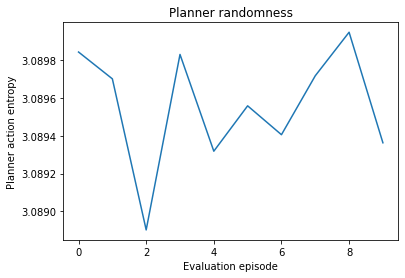

In [ ]:
import matplotlib.pyplot as plt

plt.plot(entropies)
plt.xlabel("Evaluation episode")
plt.ylabel("Planner action entropy")
plt.title("Planner randomness")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_learned_tax_system(dense_logs, last_periods=100):

    rate_levels = np.linspace(0, 0.8, 21)

    actions = np.concatenate([log["planner_actions"] for log in dense_logs.values()])
    final_actions = actions[-last_periods:]

    avg_rates = rate_levels[final_actions-1].mean(axis=0)

    brackets = np.array([0,9700,39475,84200,160725,204100,510300]) / 1000
    n = min(len(brackets), len(avg_rates))

    plt.step(brackets[:n], avg_rates[:n], where="post")
    plt.fill_between(brackets[:n], avg_rates[:n], step="post", alpha=0.3)

    plt.xlabel("Income (Coin)")
    plt.ylabel("Marginal Tax Rate")
    plt.title("Learned Tax Schedule (Final Training Periods)")
    plt.ylim(0,1)
    plt.grid(True)
    plt.show()

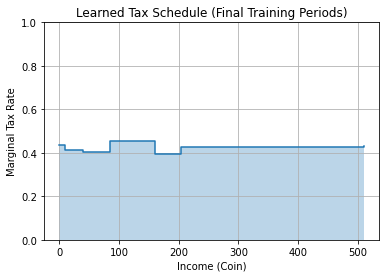

In [ ]:
plot_learned_tax_system(dense_logs, last_periods=100)

In [ ]:
env_config_dict.update(
    {
        'scenario_name': 'custom/layout_with_starts',
        'env_layout_file': 'map_100x50_water_gaps_3percent_resources.txt',
        'world_size': [100, 50]
        
    }
)

In [ ]:
env_obj = RLlibEnvWrapper({"env_config_dict": env_config_dict}, verbose=True)

[EnvWrapper] Spaces
[EnvWrapper] Obs (a)   
action_mask    : (50,)
flat           : (136,)
time           : (1,)
world-idx_map  : (2, 11, 11)
world-map      : (7, 11, 11)


[EnvWrapper] Obs (p)   
action_mask    : (154,)
flat           : (86,)
p0             : (8,)
p1             : (8,)
p2             : (8,)
p3             : (8,)
time           : (1,)
world-idx_map  : (2, 100, 50)
world-map      : (6, 100, 50)


[EnvWrapper] Action (a) Discrete(50)
[EnvWrapper] Action (p) MultiDiscrete([22 22 22 22 22 22 22])


In [ ]:
env_config = {
    "env_config_dict": env_config_dict,
    "num_envs_per_worker": trainer_config.get('num_envs_per_worker'),   
}

trainer_config.update(
    {
        "env_config": env_config        
    }
)

In [ ]:

trainer.get_policy("p").observation_space

Box(-1.0, 1.0, (40273,), float32)

(pid=None) F0312 12:09:05.736392 34116 35508 redis_client.cc:69]  Check failed: num_attempts < RayConfig::instance().redis_db_connect_retries() Expected 1 Redis shard addresses, found 2
(pid=None) *** Check failure stack trace: ***
(pid=None)     @   00007FF7E52C608C  public: __cdecl google::LogMessage::~LogMessage(void) __ptr64
(pid=None)     @   00007FF7E4FDCFB4  public: virtual __cdecl google::NullStreamFatal::~NullStreamFatal(void) __ptr64
(pid=None)     @   00007FF7E5235F8B  public: void __cdecl google::NullStreamFatal::`vbase destructor'(void) __ptr64
(pid=None)     @   00007FF7E523524B  public: void __cdecl google::NullStreamFatal::`vbase destructor'(void) __ptr64
(pid=None)     @   00007FF7E4FBE419  public: class google::NullStream & __ptr64 __cdecl google::NullStream::stream(void) __ptr64
(pid=None)     @   00007FF7E4FB463B  public: class google::NullStream & __ptr64 __cdecl google::NullStream::stream(void) __ptr64
(pid=None)     @   00007FF7E4F73787  Ordinal0
(pid=None)     @